# Example: Coil Options

In [1]:
import os 
#os.environ["JAX_PLATFORM_NAME"] = "cpu"
import jax 
jax.config.update("jax_enable_x64", True)
import jax_sbgeom
import jax.numpy as jnp
%load_ext autoreload
%autoreload 2
import numpy as onp
import matplotlib.pyplot as plt

##### Setting up geometry

Selecting a particular coil and plasma set:

In [2]:
stell_i = -1
vmec_file = ["examples/data/vmecs/helias5_vmec.nc4"][stell_i]
coil_file = ["examples/data/coils/Helias5_30.h5"][stell_i]

In [3]:
from jax_sbgeom.flux_surfaces import FluxSurfaceNormalExtendedNoPhi
from jax_sbgeom.coils         import CoilSet, DiscreteCoil, convert_to_fourier_coilset
flux_surface = FluxSurfaceNormalExtendedNoPhi.from_hdf5(vmec_file)
def _get_discrete_coils(coil_file):
    import h5py
    with h5py.File(coil_file, 'r') as f:
        coil_data = jnp.array(f['Dataset1'])
    return CoilSet.from_list([DiscreteCoil.from_positions(coil_data[i]) for i in range(coil_data.shape[0])])
coilset      = _get_discrete_coils(coil_file)

fourier_coilset = convert_to_fourier_coilset(coilset)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


We first optimize the coil winding surface:

In [4]:
from jax_sbgeom.coils import create_optimized_coil_winding_surface
n_points_per_coil = 100
n_points_toroidal = 500
cws_optimized = create_optimized_coil_winding_surface(coilset, n_points_per_coil, n_points_toroidal, surface_type = "spline")

We then interpolate using the closest mesh point. The built in raytracing works sufficiently fast here.

In [5]:
from jax_sbgeom.coils.coil_winding_surface import calculate_normals_from_closest_point_on_mesh
from jax_sbgeom.coils import FiniteSizeCoilSet, FiniteSizeCoil, RadialVectorFrame
n_coil_samples = 100
positions, normals =calculate_normals_from_closest_point_on_mesh(fourier_coilset, cws_optimized, n_coil_samples)
finitesize_coilset = FiniteSizeCoilSet(FiniteSizeCoil(fourier_coilset.coils, RadialVectorFrame(normals)))

In [6]:
coil_i = 4

In [7]:
from jax_sbgeom.coils import FiniteSizeCoilSet, RadialVectorFrame, DiscreteCoil, FiniteSizeCoil, CentroidFrame, FrenetSerretFrame, mesh_coil_surface, RotationMinimizedFrame
import pyvista as pv

closed_coil_points = finitesize_coilset[coil_i].position(jnp.linspace(0,1,200, endpoint=True))
spline = pv.Spline(closed_coil_points, n_points=200)
tube = spline.tube(radius=0.05)
#tube.plot()

grid = 100
d1 = 0.4
d2 = 0.4

m1 = mesh_coil_surface(FiniteSizeCoil.from_coil(fourier_coilset[coil_i], CentroidFrame),              grid, d1, d2)
m2 = mesh_coil_surface(FiniteSizeCoil.from_coil(fourier_coilset[coil_i], RotationMinimizedFrame, 100),grid,  d1, d2)
m3 = mesh_coil_surface(FiniteSizeCoil.from_coil(fourier_coilset[coil_i], FrenetSerretFrame),          grid, d1, d2)
m4 = mesh_coil_surface(finitesize_coilset[coil_i], grid, d1, d2)

In [8]:
from jax_sbgeom.coils.coil_meshing import _generate_vertices_from_finite_sized_lines
dummy_line = jnp.array([[0., 0., 0.], [0., 1., 0.], [1., 0., 0.], [1., 1., 0.]])
dummy_line2 = jnp.array([[0., 0., 1.], [1., 0., 1.], [0., 1., 1.], [1., 1., 1.]])
dummy_finite_size_lines = jnp.stack([dummy_line, dummy_line2])
test_vertices = _generate_vertices_from_finite_sized_lines(dummy_finite_size_lines, 5)

In [9]:

dummy_line = jnp.array([[-25.63155518,  14.16736833,   1.33269074],
                        [-24.92438292,  13.83068614,   1.16974137],
                        [-24.56225351,  14.53420829,   1.28771968],
                        [-25.26942578,  14.87089048,   1.45066905]])
dummy_finite_size_lines = jnp.stack([dummy_line])
test_vertices = _generate_vertices_from_finite_sized_lines(dummy_finite_size_lines, 5)



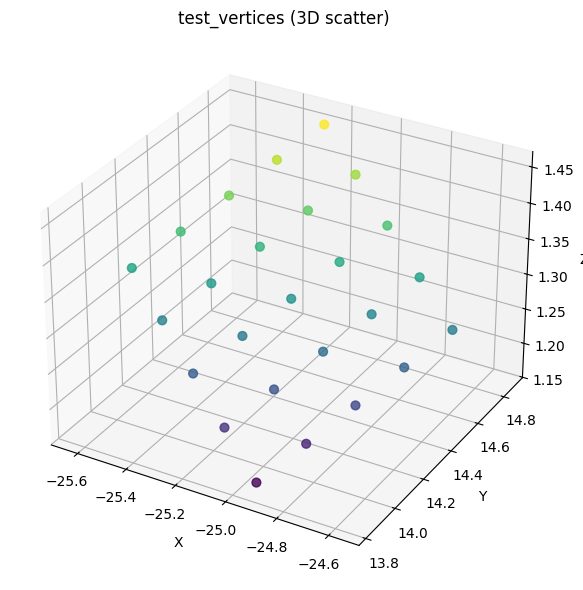

In [10]:
# test_vertices is already computed in previous cells
verts = onp.array(test_vertices).reshape(-1, 3)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(verts[:, 0], verts[:, 1], verts[:, 2], s=40, c=verts[:, 2], cmap="viridis", alpha=0.8)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("test_vertices (3D scatter)")
plt.tight_layout()
plt.show()

In [24]:
from jax_sbgeom.coils.coil_meshing import mesh_coil_volumetric
grid_density = 5
test_mesh = mesh_coil_volumetric(FiniteSizeCoil.from_coil(fourier_coilset[coil_i], CentroidFrame), grid, grid_density, d1, d2)

/home/IPP-HGW/jedwal/jax-sbgeom/.venv/lib/python3.11/site-packages/jax/_src/ops/scatter.py:104: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int64 to dtype=int32 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(


In [12]:
# from ipywidgets import interact, FloatSlider

# points, faces = test_mesh
# points = onp.array(points)

# fig = plt.figure(figsize=(10, 8))
# ax = fig.add_subplot(111, projection='3d')

# start_point = 1 - 1
# end_point = 25+1

# # ax.scatter(
# #     points[start_point:end_point, 0], points[start_point:end_point, 1], points[start_point:end_point, 2],
# #     s=2, c=points[start_point:end_point, 2], cmap="viridis", alpha=0.8
# # )

# ax.scatter(
#     points[:, 0], points[:, 1], points[:, 2],
#     s=2, c=points[:, 2], cmap="viridis", alpha=0.8
# )

# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# ax.set_zlabel("Z")
# ax.set_title("test_mesh vertices (3D scatter)")
# plt.tight_layout()
# plt.show()


In [13]:
def update_centre(mesh, dphi):
    import numpy as np 
    old_centre = np.average(mesh.points, axis=0)
    phi_old = np.arctan2(old_centre[1], old_centre[0])
    phi_new = phi_old + dphi

    r_old = np.linalg.norm(old_centre[0:2])
    new_centre = np.array([r_old * np.cos(phi_new), r_old * np.sin(phi_new), old_centre[2]]) 
    mesh.points = mesh.points - old_centre + new_centre
    old_centre = np.average(mesh.points, axis=0)
    return mesh

import pyvista as pv

In [14]:
import numpy as np
import pyvista as pv
from pyvista import CellType

In [26]:
pts, conn = test_mesh

points_onp = np.array(pts)
conn_onp = np.array(conn)

# conn_onp = conn_onp[0:1584]
# points_onp = points_onp[:1000]

# each cell is 8 points, so prepend 8 before each cell's connectivity
cells = np.hstack(
    [np.full((conn_onp.shape[0], 1), 8, dtype=np.int64), conn_onp.astype(np.int64)]
).flatten()


# cell type for hexahedra is CellType.HEXAHEDRON (12)
cell_types = np.full(conn_onp.shape[0], CellType.HEXAHEDRON, dtype=np.uint8)
# cell_types = np.full(conn_onp.shape[0], 12)

# print(cells)
# print(cell_types)
# print(points_onp)


mesh = pv.UnstructuredGrid(cells, cell_types, points_onp)

_ = mesh.plot(show_edges=True)

Widget(value='<iframe src="http://localhost:38575/index.html?ui=P_0x7f408c694590_10&reconnect=auto" class="pyv…

In [ ]:

# Contains information on the points composing each cell.
# Each cell begins with the number of points in the cell and then the points
# composing the cell
cells = np.array([8, 0, 1, 2, 3, 4, 5, 6, 7, 8, 8, 9, 10, 11, 12, 13, 14, 15])

# cell type array. Contains the cell type of each cell
cell_type = np.array([CellType.HEXAHEDRON, CellType.HEXAHEDRON])

# in this example, each cell uses separate points
cell1 = np.array(
    [
        [0, 0, 0],
        [1, 0, 0],
        [1, 1, 0],
        [0, 1, 0],
        [0, 0, 1],
        [1, 0, 1],
        [1, 1, 1],
        [0, 1, 1],
    ],
)

cell2 = np.array(
    [
        [0, 0, 2],
        [1, 0, 2],
        [1, 1, 2],
        [0, 1, 2],
        [0, 0, 3],
        [1, 0, 3],
        [1, 1, 3],
        [0, 1, 3],
    ],
)
# random_points = np.random.rand(16, 3) * 10

# points of the cell array
points = np.vstack((cell1, cell2)).astype(float)

# create the unstructured grid directly from the numpy arrays

# print(cells)
# print(cell_type)
# print(points)

grid = pv.UnstructuredGrid(cells, cell_type, points)

_ = grid.plot(show_edges=True)

# # For cells of fixed sizes (like the mentioned Hexahedra), it is also possible to use the
# # simplified dictionary interface. This automatically calculates the cell array.
# # Note that for mixing with additional cell types, just the appropriate key needs to be
# # added to the dictionary.
# cells_hex = np.arange(16).reshape([2, 8])
# # = np.array([[0, 1, 2, 3, 4, 5, 6, 7], [8, 9, 10, 11, 12, 13, 14, 15]])

# grid = pv.UnstructuredGrid({CellType.HEXAHEDRON: cells_hex}, points)

# # plot the grid (and suppress the camera position output)
# _ = grid.plot(show_edges=True)

Widget(value='<iframe src="http://localhost:32779/index.html?ui=P_0x7f290a4267d0_1&reconnect=auto" class="pyvi…

: 

In [ ]:
from jax_sbgeom.jax_utils import mesh_to_pyvista_mesh
plotter = pv.Plotter(window_size=[1600,1080])

colors = [
    "#6CA4DD",  # FW    – deep blue
    "#EBC77F",  # BZ    – warm golden
    "#E28893",  # SS    – rich red
    "#5AB4AC",  # VVF   – teal
    "#B8E186",  # SH    – light green ✅
    "#D6604D",  # VVB   – coral
]

# Define labels for the legend
labels = ["Centroid", "RMF", "Frenet", "Surface"]

# Add meshes with different colors and labels
symm = flux_surface.nfp
dphi = 0.2 * onp.pi / symm
plotter.add_mesh(tube, label = "Filament")
plotter.add_mesh(update_centre(mesh_to_pyvista_mesh(*m1), dphi), show_edges=True, color=colors[0], label=labels[0])
# plotter.add_mesh(update_centre(mesh_to_pyvista_mesh(*m2), 2 * dphi), show_edges=True, color=colors[1], label=labels[1])
# plotter.add_mesh(update_centre(mesh_to_pyvista_mesh(*m3), 3 * dphi), show_edges=True, color=colors[2], label=labels[2])
# plotter.add_mesh(update_centre(mesh_to_pyvista_mesh(*m4), 4 * dphi), show_edges=True, color=colors[3], label=labels[3])
plotter.add_mesh(update_centre(mesh_to_pyvista_mesh(*test_mesh), 3 * dphi), show_edges=True, color=colors[4], label=labels[3])

# Add legend with custom formatting
plotter.add_legend(bcolor='white', face='rectangle', size=(0.4, 0.2))
plotter.camera.position = (-1.2247604357068038, -29.629398815049722, 10.706413666000861)
plotter.camera.focal_point = (-15.014994211475743, -0.5471979244841606, 1.9702799652443908)
plotter.camera.up =  (-0.11057139781760415, 0.23747396462331735, 0.9650803500801085)
plotter.show()  # Render and keep the window open
#plotter.screenshot(filename=f"fig_{fig_id}_coil_different_finite_size.png", window_size=[1600, 1080])
plotter.close()  # Close t

### To get plotter camer position, run this in next cell when the plotter is active
### print(plotter.camera_position)